In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
from kan import *
from kan.utils import ex_round
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from time import time
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


#### Data source: https://www.kaggle.com/datasets/nikunjhemani/freddie-macs-dataset-pre-processed/code
#### Feature selection: https://www.kaggle.com/code/missionjee/feature-selection

In [2]:
# Step 1: Load the Data
train_path = 'FreddieMac_train.csv'
test_path = 'FreddieMac_valid.csv'
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

train_data['LTV_range'] = train_data['LTV_range'].map({'Low': -1, 'Medium': 0, 'High':1})
test_data['LTV_range'] = test_data['LTV_range'].map({'Low': -1, 'Medium': 0, 'High':1})
train_data['Credit_range'] = train_data['Credit_range'].map({'Poor': -1, 'Fair': 0, 'Good': 1})
test_data['Credit_range'] = test_data['Credit_range'].map({'Poor': -1, 'Fair': 0, 'Good': 1})
# Step 2: Prepare the Data
# [2:14] 14,13,2,9,10,6
'''features = df[['Repay_range', 'LTV_range', 'FirstTimeHomebuyer', 'NumBorrowers','MonthsInRepayment', 'OrigUPB', 
               'OrigInterestRate', 'MIP', 'Maturity_Year', 'FirstPayment_Year','MSA', 'DTI']].values'''

x_train = train_data.iloc[:, [14,10]].values  # Input columns
y_train = train_data.iloc[:, [15]].values  # Input columns
x_test = test_data.iloc[:, [14,10]].values  # Input columns
y_test = test_data.iloc[:, [15]].values  # Input columns

# Step 3: Min-Max Scaling
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_train = scaler_X.fit_transform(x_train)
X_test = scaler_X.transform(x_test)
Y_train = scaler_Y.fit_transform(y_train.reshape(-1, 1)).flatten()
Y_test = scaler_Y.transform(y_test.reshape(-1, 1)).flatten()

# Step 5: Convert to Torch Tensors and Create Dataset Format
train_input = torch.tensor(X_train, dtype=torch.double)
train_label = torch.tensor(Y_train, dtype=torch.double).unsqueeze(1)

test_input = torch.tensor(X_test, dtype=torch.double)
test_label = torch.tensor(Y_test, dtype=torch.double).unsqueeze(1)

# Creating the dataset dictionary
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': test_input,
    'test_label': test_label
}

print(X_test[:2,])

# Checking the shape of the tensors
print(dataset['train_input'].shape, dataset['train_label'].shape)
print(dataset['test_input'].shape, dataset['test_label'].shape)

[[0.         0.08530806]
 [0.5        0.52132701]]
torch.Size([59999, 2]) torch.Size([59999, 1])
torch.Size([15000, 2]) torch.Size([15000, 1])


In [3]:
# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


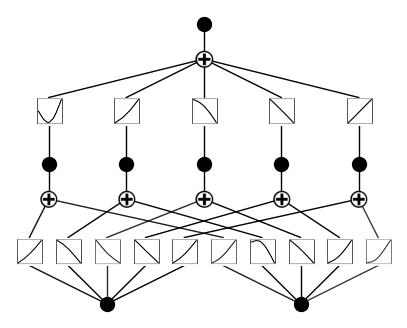

In [4]:
# plot KAN at initialization
model(dataset['train_input'])
model.plot()

In [5]:
# train the model
model.fit(dataset, opt="LBFGS", steps=100)

| train_loss: 2.42e-01 | test_loss: 3.18e-01 | reg: 1.32e+01 | : 100%|█| 100/100 [25:27<00:00, 15.28


saving model version 0.1


{'train_loss': [array(0.24180447),
  array(0.24177139),
  array(0.24176152),
  array(0.24175858),
  array(0.24175597),
  array(0.24175623),
  array(0.24175383),
  array(0.24175298),
  array(0.24175166),
  array(0.24175121),
  array(0.2417506),
  array(0.24174958),
  array(0.24174911),
  array(0.24174809),
  array(0.24174751),
  array(0.24174778),
  array(0.24174657),
  array(0.24174621),
  array(0.24174559),
  array(0.24174515),
  array(0.24174517),
  array(0.24174437),
  array(0.24174363),
  array(0.24174332),
  array(0.24174305),
  array(0.24174583),
  array(0.24174455),
  array(0.24174398),
  array(0.24174378),
  array(0.24174348),
  array(0.24174308),
  array(0.24174223),
  array(0.24174168),
  array(0.24174089),
  array(0.24174042),
  array(0.24174313),
  array(0.24174086),
  array(0.24173929),
  array(0.2417388),
  array(0.24173744),
  array(0.24174122),
  array(0.24174093),
  array(0.24174059),
  array(0.24174042),
  array(0.24174034),
  array(0.24174168),
  array(0.24174115),
 

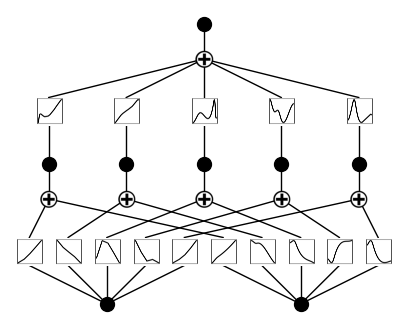

In [6]:
model.plot()

saving model version 0.2


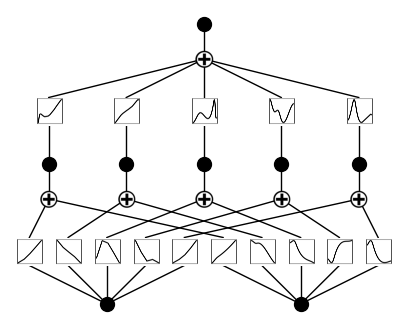

In [7]:
model = model.prune()
model.plot()

In [8]:
model.fit(dataset, opt="LBFGS", steps=100)

| train_loss: 2.42e-01 | test_loss: 3.18e-01 | reg: 1.27e+01 | : 100%|█| 100/100 [29:28<00:00, 17.68


saving model version 0.3


{'train_loss': [array(0.24181478),
  array(0.2417872),
  array(0.24176132),
  array(0.24175305),
  array(0.24175198),
  array(0.24176261),
  array(0.24175717),
  array(0.24175615),
  array(0.24175565),
  array(0.24175506),
  array(0.24175644),
  array(0.24175486),
  array(0.24175414),
  array(0.24175334),
  array(0.24175304),
  array(0.24175316),
  array(0.24175292),
  array(0.24175236),
  array(0.2417519),
  array(0.24175167),
  array(0.24175152),
  array(0.2417509),
  array(0.24175038),
  array(0.24175003),
  array(0.24174968),
  array(0.2417504),
  array(0.24174957),
  array(0.24174945),
  array(0.24174936),
  array(0.24174903),
  array(0.24174934),
  array(0.24174918),
  array(0.24174911),
  array(0.24174905),
  array(0.24174897),
  array(0.24174891),
  array(0.24174862),
  array(0.24174839),
  array(0.24174824),
  array(0.24174815),
  array(0.24174791),
  array(0.24174744),
  array(0.24174733),
  array(0.24174723),
  array(0.24174693),
  array(0.24174738),
  array(0.24174705),
  a

In [17]:
model = model.refine(5)
model.fit(dataset, opt="LBFGS", steps=100)

saving model version 0.8


| train_loss: 2.42e-01 | test_loss: 3.18e-01 | reg: 1.22e+01 | : 100%|█| 100/100 [26:20<00:00, 15.81

saving model version 0.9


{'train_loss': [array(0.24179669),
  array(0.24176192),
  array(0.24175051),
  array(0.24174907),
  array(0.24174812),
  array(0.24177982),
  array(0.24176264),
  array(0.24176176),
  array(0.2417596),
  array(0.24175862),
  array(0.241772),
  array(0.24176637),
  array(0.24176172),
  array(0.24175749),
  array(0.24175259),
  array(0.24196069),
  array(0.24177017),
  array(0.24175871),
  array(0.24175436),
  array(0.241753),
  array(0.24177682),
  array(0.24175226),
  array(0.24175193),
  array(0.24175177),
  array(0.24175116),
  array(0.24175369),
  array(0.24175124),
  array(0.24175055),
  array(0.2417504),
  array(0.24175009),
  array(0.24175345),
  array(0.24175111),
  array(0.24175043),
  array(0.24174984),
  array(0.24174967),
  array(0.24175907),
  array(0.24175114),
  array(0.24175008),
  array(0.24174969),
  array(0.2417492),
  array(0.24175113),
  array(0.24174905),
  array(0.24174894),
  array(0.24174886),
  array(0.24174874),
  array(0.24175473),
  array(0.24175165),
  arra

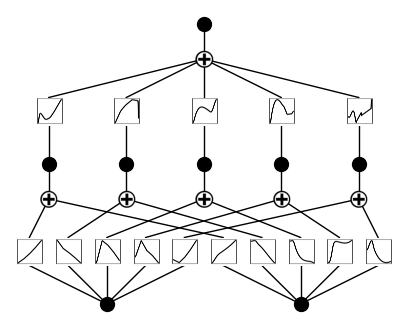

In [18]:
model.plot()

In [20]:
model = model.refine(10)
model.fit(dataset, opt="LBFGS", steps=100)

saving model version 0.12


| train_loss: 2.42e-01 | test_loss: 3.18e-01 | reg: 1.25e+01 | : 100%|█| 100/100 [38:24<00:00, 23.04

saving model version 0.13


{'train_loss': [array(0.24173608),
  array(0.24172046),
  array(0.2417155),
  array(0.24171402),
  array(0.24171263),
  array(0.24171219),
  array(0.24171003),
  array(0.24170929),
  array(0.24170845),
  array(0.24170788),
  array(0.24171052),
  array(0.24170738),
  array(0.24170702),
  array(0.24170687),
  array(0.24170661),
  array(0.24171088),
  array(0.24170728),
  array(0.24170585),
  array(0.24170549),
  array(0.2417053),
  array(0.24170581),
  array(0.24170556),
  array(0.24170534),
  array(0.24170511),
  array(0.24170504),
  array(0.24170688),
  array(0.24170594),
  array(0.2417055),
  array(0.24170535),
  array(0.24170514),
  array(0.24170674),
  array(0.24170574),
  array(0.24170549),
  array(0.2417053),
  array(0.24170519),
  array(0.24170722),
  array(0.2417058),
  array(0.24170515),
  array(0.24170493),
  array(0.2417047),
  array(0.24170476),
  array(0.24170453),
  array(0.24170419),
  array(0.2417039),
  array(0.24170324),
  array(0.24170375),
  array(0.24170314),
  arra

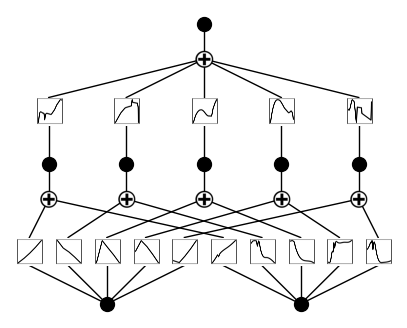

In [21]:
model.plot()

model = model.refine(25)
model.fit(dataset, opt="LBFGS", steps=100)

model.plot()

In [22]:
X_test = dataset['test_input']  # Shape: (n_samples, 6)
Y_test = dataset['test_label']  # Shape: (n_samples,)

Y_pred_KAN = model(X_test)

In [23]:
X_test_np = X_test.cpu().numpy() if X_test.is_cuda else X_test.numpy()
Y_test_np = Y_test.cpu().numpy() if Y_test.is_cuda else Y_test.numpy()
Y_test_pred_np = Y_pred_KAN.cpu().detach().numpy() if Y_pred_KAN.is_cuda else Y_pred_KAN.detach().numpy()

# Combine X_test, Y_test, and Y_test_pred into a single DataFrame
data = np.hstack((X_test_np, Y_test_np.reshape(-1, 1), Y_test_pred_np.reshape(-1, 1)))
columns = [f"x{i+1}" for i in range(X_test_np.shape[1])] + ["y_test", "y_test_pred_KAN"]

# Create a DataFrame
df = pd.DataFrame(data, columns=columns)

# Export the DataFrame to a CSV file
output_file = "KAN_predictions.csv"
df.to_csv(output_file, index=False)

print(f"Predictions exported to {output_file}")


Predictions exported to KAN_predictions.csv


In [24]:
Y_pred_KAN_np = Y_pred_KAN.detach().numpy()
y_pred_KAN = scaler_Y.inverse_transform(Y_pred_KAN_np)
#y_test = scaler_Y.inverse_transform(Y_test.reshape(-1, 1))

KAN_mae = mean_absolute_error(y_test, y_pred_KAN)
KAN_mape = np.mean(np.abs((y_test - y_pred_KAN) / y_test)) * 100  # Mean Absolute Percentage Error
KAN_mse = mean_squared_error(y_test, y_pred_KAN)
KAN_rmse = np.sqrt(KAN_mse)  # Root Mean Squared Error
KAN_rmspe = np.sqrt(np.mean(np.square((y_test - y_pred_KAN) / y_test))) * 100  # Root Mean Square Percentage Error
KAN_r2 = r2_score(y_test, y_pred_KAN)

# Printing the metrics
print(f"KAN Mean Absolute Error (MAE): {KAN_mae:.4f}")
print(f"KAN Mean Absolute Percentage Error (MAPE): {KAN_mape:.4f}%")
print(f"KAN Mean Squared Error (MSE): {KAN_mse:.4f}")
print(f"KAN Root Mean Squared Error (RMSE): {KAN_rmse:.4f}")
print(f"KAN Root Mean Square Percentage Error (RMSPE): {KAN_rmspe:.4f}%")
print(f"KAN R-squared (R2): {KAN_r2:.4f}")

KAN Mean Absolute Error (MAE): 0.6352
KAN Mean Absolute Percentage Error (MAPE): 63.5184%
KAN Mean Squared Error (MSE): 0.4037
KAN Root Mean Squared Error (RMSE): 0.6354
KAN Root Mean Square Percentage Error (RMSPE): 63.5379%
KAN R-squared (R2): 0.0000


In [25]:
SYMBOLIC_LIB.keys()

dict_keys(['x', 'x^2', 'x^3', 'x^4', 'x^5', '1/x', '1/x^2', '1/x^3', '1/x^4', '1/x^5', 'sqrt', 'x^0.5', 'x^1.5', '1/sqrt(x)', '1/x^0.5', 'exp', 'log', 'abs', 'sin', 'cos', 'tan', 'tanh', 'sgn', 'arcsin', 'arccos', 'arctan', 'arctanh', '0', 'gaussian'])

In [ ]:
mode = "auto" # "manual"
t_init = time()

if mode == "manual":
    # manual mode
    model.fix_symbolic(0,0,0,'sin')
    model.fix_symbolic(0,1,0,'x^2')
    model.fix_symbolic(1,0,0,'exp')
elif mode == "auto":
    # automatic mode
    lib = ['x', 'x^0.5','x^2','x^3','x^4','1/x','1/x^0.5','1/x^2','1/x^3','1/x^4','exp','log','sqrt','tanh','sin','tan','abs', 'gaussian', 'sgn', '0']
    model.auto_symbolic(lib=None, weight_simple=0) # Lib none uses all of symbolic library, weight_simple asks for function fit complexity, 0 is complex and requires time
t_conv = time() - t_init
print("The conversion time is:",t_conv/60,"minutes.")

In [ ]:
output = ex_round(model.symbolic_formula()[0][0], 4)
print('After rounding, the formula is:\n',output)

output_type = type(output)
print('output type is', output_type)

In [ ]:
output

In [ ]:
# Assuming your symbolic expression (e.g., Y = x_1 + x_2 * x_3 + ...) 
# Replace this with your actual symbolic expression
x_1, x_2, x_3, x_4, x_5, x_6 = symbols('x_1 x_2 x_3 x_4 x_5 x_6') 
symbolic_expr = model.symbolic_formula()[0][0]

# Extract test data inputs and labels
X_test = dataset['test_input']  # Shape: (n_samples, 6)
Y_test = dataset['test_label']  # Shape: (n_samples,)

# List of symbols to map test_input to the symbolic expression
variables = [x_1, x_2, x_3, x_4, x_5, x_6]

In [ ]:
# Evaluate symbolic expression for each row in X_test
Y_pred_sym = []
for row in X_test:
    # Create a dictionary to map symbolic variables to values
    inputs = {var: value for var, value in zip(variables, row)}
    # Evaluate the symbolic expression and use evalf() to get a float value
    Y_pred_sym.append(float(symbolic_expr.subs(inputs).evalf()))

In [ ]:
# Convert predictions to NumPy array and reshape 
Y_pred_sym = np.array(Y_pred_sym).reshape(-1, 1)

# Inverse scale predictions and ground truth
y_pred_sym = scaler_Y.inverse_transform(Y_pred_sym)
#y_test = scaler_Y.inverse_transform(Y_test.reshape(-1, 1))

In [ ]:
# Compute R^2 score
sym_mae = mean_absolute_error(y_test, y_pred_sym)
sym_mape = np.mean(np.abs((y_test - y_pred_sym) / y_test)) * 100  # Mean Absolute Percentage Error
sym_mse = mean_squared_error(y_test, y_pred_sym)
sym_rmspe = np.sqrt(np.mean(np.square((y_test - y_pred_sym) / y_test))) * 100  # Root Mean Square Percentage Error
sym_rmse = np.sqrt(sym_mse)  # Root Mean Squared Error
sym_r2 = r2_score(y_test, y_pred_sym)

# Printing the metrics
print(f"Symbolic Mean Absolute Error (MAE): {sym_mae:.4f}")
print(f"Symbolic Mean Absolute Percentage Error (MAPE): {sym_mape:.4f}%")
print(f"Symbolic Mean Squared Error (MSE): {sym_mse:.4f}")
print(f"Symbolic Root Mean Squared Error (RMSE): {sym_rmse:.4f}")
print(f"Symbolic Root Mean Square Percentage Error (RMSPE): {sym_rmspe:.4f}%")
print(f"Symbolic R-squared (R2): {sym_r2:.4f}")

In [ ]:
# Combine X_test, Y_test, and Y_test_pred into a single DataFrame
data = np.hstack((X_test_np, Y_test_np.reshape(-1, 1), Y_test_pred_np.reshape(-1, 1)))
columns = [f"x{i+1}" for i in range(X_test_np.shape[1])] + ["y_test", "y_test_pred_KAN"]

# Create a DataFrame
df = pd.DataFrame(data, columns=columns)

# Export the DataFrame to a CSV file
output_file = "KAN_eqn_predictions.csv"
df.to_csv(output_file, index=False)

print(f"Predictions exported to {output_file}")